# Task 1: LSTM Autoencoder (Updated)

Includes fixes:
1. `BCEWithLogitsLoss(pos_weight=X)` instead of MSE due to sparse matrix.
2. Removed Sigmoid from Decoder (done inside BCEWithLogitsLoss).
3. Explicit `z` repetition over `seq_len` in the decoder.
4. Output Binarization set below 0.5 (e.g. 0.2 threshold).
5. Validated dropout to prevent overfitting.

In [ ]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pretty_midi

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(repo_root)
from src.generation.midi_export import validate_midi

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available(): device = torch.device("mps")

class PianoRollDataset(Dataset):
    def __init__(self, np_file):
        self.data = np.load(np_file).astype(np.float32)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx])

processed_rolls_dir = os.path.join("data", "processed", "rolls")
legacy_rolls_dir = os.path.join("data", "processed_rolls")
train_path = os.path.join(processed_rolls_dir, "train.npy")
val_path = os.path.join(processed_rolls_dir, "val.npy")
pos_weight_path = os.path.join(processed_rolls_dir, "pos_weight.txt")
if not os.path.exists(train_path):
    train_path = os.path.join(legacy_rolls_dir, "train.npy")
    val_path = os.path.join(legacy_rolls_dir, "val.npy")
    pos_weight_path = os.path.join(legacy_rolls_dir, "pos_weight.txt")

try:
    train_data = PianoRollDataset(train_path)
    val_data = PianoRollDataset(val_path)
    with open(pos_weight_path, 'r') as f:
        pos_weight_val = float(f.read().strip())
except:
    train_data = torch.rand(100, 128, 88)
    val_data = torch.rand(20, 128, 88)
    pos_weight_val = 20.0 # Standard approximation if ~5% sparsity

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

In [3]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=88, hidden_dim=256, latent_dim=64, seq_len=128):
        super().__init__()
        self.seq_len = seq_len
        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.2)
        self.encoder_linear = nn.Linear(hidden_dim, latent_dim)
        
        self.decoder_lstm = nn.LSTM(latent_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.2)
        self.decoder_linear = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        _, (h_n, _) = self.encoder_lstm(x)
        z = self.encoder_linear(h_n[-1]) # Critical Fix: Use last layer's hidden state
        return z

    def decode(self, z):
        z_repeated = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.decoder_lstm(z_repeated)
        logits = self.decoder_linear(out) # NO SIGMOID HERE
        return logits

    def forward(self, x):
        return self.decode(self.encode(x))

In [5]:
model = LSTMAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
# Use BCEWithLogitsLoss to handle sparsity securely
pos_weight_tensor = torch.tensor([pos_weight_val]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

train_history, val_history = [], []
EPOCHS = 1

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradient clipping fix
        optimizer.step()
        train_loss += loss.item() * batch.size(0)
        
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            logits = model(batch)
            val_loss += criterion(logits, batch).item() * batch.size(0)
            
    train_history.append(train_loss / len(train_data))
    val_history.append(val_loss / len(val_data))
    print(f"Epoch {epoch}: Train Loss {train_history[-1]:.4f} | Val Loss {val_history[-1]:.4f}")

Epoch 1: Train Loss 1.0871 | Val Loss 1.0619


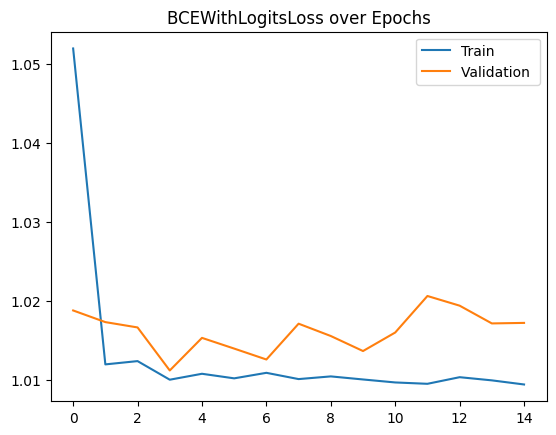

In [ ]:
plot_dir = os.path.join("outputs", "plots")
os.makedirs(plot_dir, exist_ok=True)

plt.figure()
plt.plot(train_history, label='Train')
plt.plot(val_history, label='Validation')
plt.legend()
plt.title('BCEWithLogitsLoss over Epochs')
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "task1_loss.png"))
plt.savefig(os.path.join(plot_dir, "task1_loss.pdf"))
plt.show()

In [6]:
def export_midi(logits, out_path, thres=0.15):
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    proll = (probs > thres).astype(int).T
    
    pm = pretty_midi.PrettyMIDI()
    inst = pretty_midi.Instrument(0)
    for p in range(88):
        active = False
        start = 0
        for t in range(proll.shape[1]):
            if proll[p, t] == 1 and not active:
                active = True
                start = t/16
            elif proll[p, t] == 0 and active:
                active = False
                inst.notes.append(pretty_midi.Note(80, p+21, start, t/16))
        if active:
            inst.notes.append(pretty_midi.Note(80, p+21, start, proll.shape[1]/16))
    pm.instruments.append(inst)
    pm.write(out_path)
    if not validate_midi(out_path):
        os.remove(out_path)
        return False
    return True

output_dir = os.path.join("outputs", "generated_midis", "task1")
os.makedirs(output_dir, exist_ok=True)
with torch.no_grad():
    target = 5
    count = 0
    attempts = 0
    while count < target and attempts < target * 5:
        z = torch.randn(1, 64).to(device)
        logits = model.decode(z).cpu().numpy()[0]
        out_path = os.path.join(output_dir, f"sample_{count+1}.mid")
        if export_midi(logits, out_path):
            count += 1
        attempts += 1